# Лабораторная работа 9

## Методы обучения без учителя.

### Цель лабораторной работы: изучение методов кластеризации и снижения размерности.

# Датасет:
Текстовое описание набора данных
Набор данных по исследованию качества воздуха - https://archive.ics.uci.edu/dataset/360/air+quality

Набор содержит почасовые данные, полученные от комбинированного газоанализатора, установленного в итальянском городе вблизи автомобильной магистрали. Данные записывались с Марта 2004 по февраль 2005 (один год).

Датасет состоит из 2-х файлов одинаковых данных в формате .csv и .xlsx

Каждый файл содержит следующие колонки:

Date дата в формате ДЕНЬ-МЕСЯЦ-ГОД Набор данных содержит данные с интервалом измерения в один час.
Time время в формате ЧАСЫ:МИНУТЫ:СЕКУНДЫ.
CO(GT) концентрация СО mg/m^3
PT08.S1(CO) концентрация СО mg/m^3 усредненная за час
NMHC(GT) максимальная концентрация паров гидрокарбонатов усредненная за час microg/m^3
C6H6(GT) максимальная концентрация паров бензина усредненная за час microg/m^3
PT08.S2(NMHC) концентрация паров гидрокарбонатов усредненная за час microg/m^3
NOx(GT) максимальная концентрация оксидов азота усредненная за час microg/m^3
PT08.S3(NOx) концентрация оксидов азота усредненная за час microg/m^3
NO2(GT) максимальная концентрация двуокиси азота усредненная за час microg/m^3
PT08.S4(NO2) концентрация двуокиси азота усредненная за час microg/m^3
PT08.S5(O3) концентрация озона усредненная за час microg/m^3
T температура в градусах Цельсия
RH относительная влажность в %.
AH абсолютная влажность в %.
Category категория качества воздуха - Good/Bad


In [260]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import datasets
from sklearn.cluster import KMeans, MiniBatchKMeans, MeanShift, SpectralClustering
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, homogeneity_completeness_v_measure, silhouette_score
import warnings

In [261]:
# 
data = pd.read_csv('air+quality/2.csv', sep=";")
data = data.drop(columns=['Unnamed: 16'])

In [262]:
# Первые 5 строк датасета
data.head()

,Date,Time,COGT,PT08S1CO,NMHCGT,C6H6GT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,PT08S5O3,T,RH,AH,Category
0,10.03.2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268,13.6,48.9,0.7578,Bad
1,10.03.2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972,13.3,47.7,0.7255,Bad
2,10.03.2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074,11.9,54.0,0.7502,Bad
3,10.03.2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203,11.0,60.0,0.7867,Bad
4,10.03.2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110,11.2,59.6,0.7888,Good


In [263]:
#Удаление строк с пропусками
data = data.dropna(axis=0, how='any')
data.shape

(827, 16)

In [264]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 0 to 1230
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        827 non-null    object 
 1   Time        827 non-null    object 
 2   COGT        827 non-null    float64
 3   PT08S1CO    827 non-null    float64
 4   NMHCGT      827 non-null    float64
 5   C6H6GT      827 non-null    float64
 6   PT08S2NMHC  827 non-null    float64
 7   NOxGT       827 non-null    float64
 8   PT08S3NOx   827 non-null    float64
 9   NO2GT       827 non-null    float64
 10  PT08S4NO2   827 non-null    float64
 11  PT08S5O3    827 non-null    int64  
 12  T           827 non-null    float64
 13  RH          827 non-null    float64
 14  AH          827 non-null    float64
 15  Category    827 non-null    object 
dtypes: float64(12), int64(1), object(3)
memory usage: 109.8+ KB


In [265]:
data.describe()

,COGT,PT08S1CO,NMHCGT,C6H6GT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,PT08S5O3,T,RH,AH
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000
mean,2.353567,1207.879081,231.025393,10.771100,966.116082,143.501814,963.297461,100.259976,1600.620314,1045.812576,15.601451,49.050181,0.831853
std,1.409496,241.816997,208.461912,7.418134,266.424557,81.829717,265.914168,31.493823,302.291793,400.134662,4.825304,15.266746,0.178506
min,0.300000,753.000000,7.000000,0.500000,448.000000,12.000000,461.000000,19.000000,955.000000,263.000000,6.300000,14.900000,0.402300
25%,1.300000,1017.000000,77.000000,4.800000,754.000000,81.000000,769.000000,78.500000,1369.500000,760.000000,11.900000,36.700000,0.718950
50%,2.000000,1172.000000,157.000000,9.100000,944.000000,128.000000,920.000000,99.000000,1556.000000,1009.000000,15.000000,49.600000,0.817700
75%,3.100000,1380.000000,318.500000,14.800000,1142.500000,187.000000,1131.000000,122.000000,1783.500000,1320.000000,18.300000,60.550000,0.927500
max,8.100000,2040.000000,1189.000000,39.200000,1754.000000,478.000000,1935.000000,196.000000,2679.000000,2359.000000,30.000000,83.200000,1.485200


In [266]:
d1 = data[['COGT','C6H6GT','NOxGT','NO2GT']]

In [267]:
#Преобразование категориальных признаков в числовые
from sklearn.preprocessing import OrdinalEncoder
data_oe = data[['Category']]
oe = OrdinalEncoder()
enc_oe = oe.fit_transform(data_oe)

## Метод главных компонент

In [268]:
pca = PCA(n_components=2)
d2 = pca.fit_transform(d1)
print('Доля объясненной дисперсии: {}, сумма={}'.format(pca.explained_variance_ratio_, np.sum(pca.explained_variance_ratio_)))
d2[:10]

Доля объясненной дисперсии: [0.96857153 0.03048884], сумма=0.9990603675303575


array([[  25.42054263,    4.75023341],
       [ -40.97400848,    5.3361429 ],
       [  -7.5004833 ,   17.01728867],
       [  33.76040991,   11.24690229],
       [  -7.06425624,   18.85206647],
       [ -53.27368642,   13.5676482 ],
       [ -84.95302066,    4.36531833],
       [ -85.30271806,    3.4128814 ],
       [-106.57752156,   -6.20456725],
       [-144.34811479,  -27.04865241]])

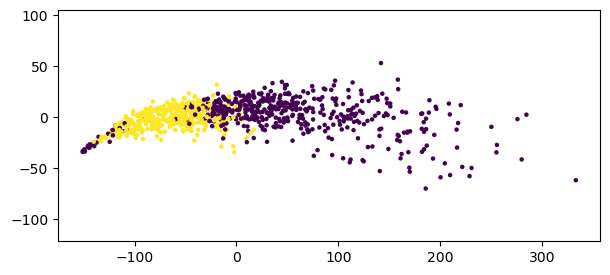

In [269]:
plt.figure(figsize=(7,3))
plt.scatter(d2[:, 0], d2[:, 1], s=5, c=enc_oe)
plt.axis('equal')
plt.show()

##  Aлгоритм t-SNE 

In [270]:
tsne = TSNE(n_components=2)
d3 = tsne.fit_transform(d1)
d3[:10]

array([[ 15.965104 ,  11.142549 ],
       [-14.401245 ,  14.479646 ],
       [  2.7000172,  24.16099  ],
       [ 19.911953 ,   9.594802 ],
       [  2.780308 ,  24.73291  ],
       [-22.021852 ,  13.267108 ],
       [-30.176445 ,  -7.098865 ],
       [-29.918562 ,  -7.624111 ],
       [-31.632286 , -22.589972 ],
       [-27.692247 , -35.54908  ]], dtype=float32)

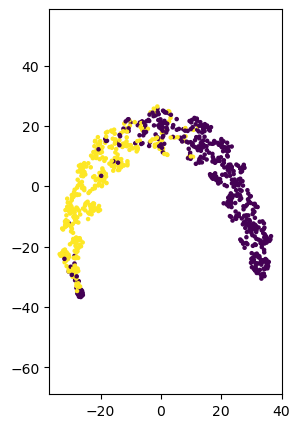

In [271]:
plt.figure(figsize=(3,5))
plt.scatter(d3[:, 0], d3[:, 1], s=5, c=enc_oe)
plt.axis('equal')
plt.show()


## Кластеризация

In [272]:
def visualize_clusters(X, cluster_results):
    """
    Визуализация результатов кластерного анализа
    """
    plt.figure(figsize=(3,5))
    plt.scatter(X[:, 0], X[:, 1], s=5, c=cluster_results)
    plt.xticks(())
    plt.yticks(())
   
    plt.show()

In [273]:
def claster_metrics(method, cluster_dataset, cluster_true_y, dataset_name):
    """
    Вычисление метрик кластеризации
    """
    temp_cluster = method.fit_predict(cluster_dataset)
    ari=adjusted_rand_score(cluster_true_y, temp_cluster)
    ami=adjusted_mutual_info_score(cluster_true_y, temp_cluster)
    
    hl, cl, vl = homogeneity_completeness_v_measure(cluster_true_y, temp_cluster)

    sl = 0
    try:
         sscore = silhouette_score(cluster_dataset, temp_cluster)
    except:
        sscore = None
            
        sl=sscore


    
    result = pd.DataFrame({'Dataset':[dataset_name], 
                           'ARI':[ari], 'AMI':[ami], 
                           'Homogeneity':[hl], 
                           'Completeness':[cl], 
                           'V-measure':[vl], 'Silhouette':[sl]})
    return result

## Метод k-средних

In [274]:
def do_clustering(X, method):
    """
    Выполнение кластеризации для данных примера
    """
    cluster_results = []
    
#    for X in cluster_datasets:
    temp_cluster = method.fit_predict(X)
    cluster_results.append(temp_cluster)
    return cluster_results

In [275]:
%time result_KMeans_31 = do_clustering(d1, KMeans(n_clusters=2,random_state=0, n_init="auto"))

CPU times: user 2.41 ms, sys: 847 μs, total: 3.26 ms
Wall time: 2.57 ms


In [276]:
%time result_KMeans_32 = do_clustering(d2, KMeans(n_clusters=2,random_state=0, n_init="auto"))

CPU times: user 1.33 ms, sys: 1.62 ms, total: 2.95 ms
Wall time: 2.06 ms


In [277]:
%time result_KMeans_33 = do_clustering(d3, KMeans(n_clusters=2,random_state=0, n_init="auto"))

CPU times: user 2.27 ms, sys: 335 μs, total: 2.61 ms
Wall time: 1.85 ms


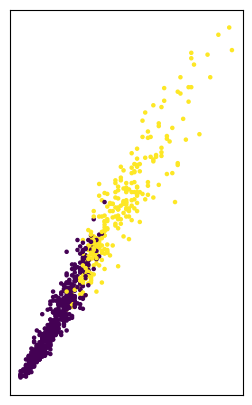

In [278]:
visualize_clusters(np.array(d1), result_KMeans_31)

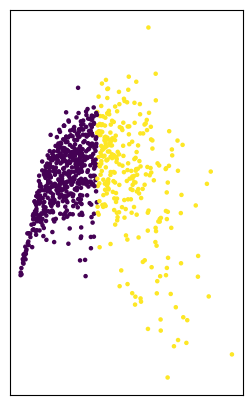

In [279]:
visualize_clusters(d2, result_KMeans_32)

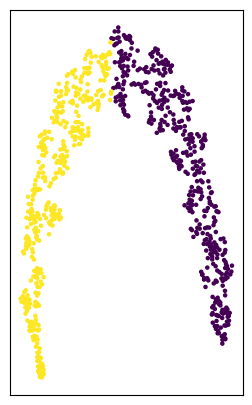

In [280]:
visualize_clusters(d3, result_KMeans_33)

In [281]:
claster_metrics( KMeans(n_clusters=2,random_state=0, n_init="auto"), np.array(d1), enc_oe[:,0], 'Data_D1')

,Dataset,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Data_D1,0.292603,0.389115,0.378087,0.401992,0.389673,0


In [282]:
claster_metrics( KMeans(n_clusters=2,random_state=0, n_init="auto"), d2, enc_oe[:,0], 'Data_D2')

,Dataset,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Data_D2,0.289954,0.38742,0.376219,0.4005,0.38798,0


In [283]:
claster_metrics( KMeans(n_clusters=2,random_state=0, n_init="auto"), d3, enc_oe[:,0], 'Data_D3')

,Dataset,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Data_D3,0.559673,0.45683,0.459874,0.454772,0.457308,0


## Mean Shift

In [284]:
%time result_MS_1 = do_clustering(np.array(d1), MeanShift())

CPU times: user 2.36 s, sys: 0 ns, total: 2.36 s
Wall time: 2.36 s


In [285]:
%time result_MS_2 = do_clustering(d2, MeanShift())

CPU times: user 2.38 s, sys: 0 ns, total: 2.38 s
Wall time: 2.38 s


In [286]:
%time result_MS_3 = do_clustering(d3, MeanShift())

CPU times: user 2.88 s, sys: 0 ns, total: 2.88 s
Wall time: 2.88 s


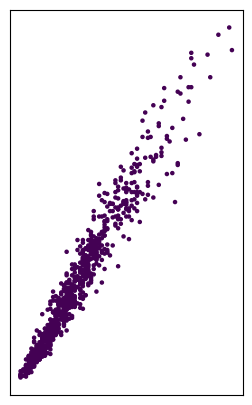

In [287]:
visualize_clusters(np.array(d1), result_MS_1)

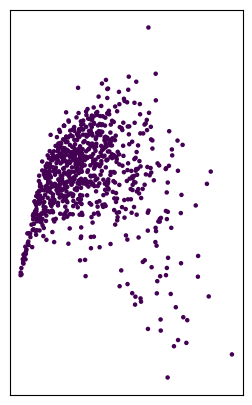

In [288]:
visualize_clusters(d2, result_MS_2)

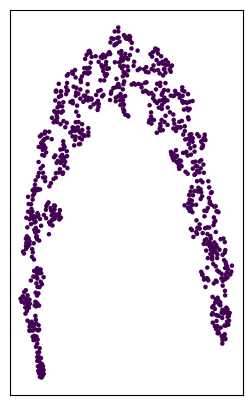

In [289]:
visualize_clusters(d3, result_MS_3)

In [290]:
claster_metrics( MeanShift(), np.array(d1), enc_oe[:,0], 'Data_D1')

,Dataset,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Data_D1,0.0,0.0,0.0,1.0,0.0,None


In [291]:
claster_metrics( MeanShift(), d2, enc_oe[:,0], 'Data_D2')

,Dataset,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Data_D2,0.0,0.0,0.0,1.0,0.0,None


In [292]:
claster_metrics( MeanShift(), d3, enc_oe[:,0], 'Data_D3')

,Dataset,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Data_D3,0.0,0.0,0.0,1.0,0.0,None


## Spectral clustering

In [293]:
%time result_SC_1 = do_clustering(np.array(d1), SpectralClustering())

/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


CPU times: user 1min 38s, sys: 30 s, total: 2min 8s
Wall time: 50 s


/home/maria/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:425: RuntimeWarning: invalid value encountered in add
  distances += XX
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:700: RuntimeWarning: overflow encountered in square
  lloyd_iter(
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [294]:
%time result_SC_2 = do_clustering(d2, SpectralClustering())

/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


CPU times: user 1min 43s, sys: 31.8 s, total: 2min 15s
Wall time: 53 s


/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited at iteration 781 with accuracies 
[4.93612848e-14 2.55603607e-06 9.41233851e-06 1.62881656e-05
 5.42568429e-06 8.77157573e-06 1.10149476e-05 1.99368089e-05
 1.18919164e-05]
not reaching the requested tolerance 1.2323260307312012e-05.
Use iteration 730 instead with accuracy 
9.130068469434435e-06.

  _, diffusion_map = lobpcg(
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited postprocessing with accuracies 
[3.44190936e-14 2.59970733e-06 9.91632730e-06 1.64696389e-05
 5.75921091e-06 9.20480288e-06 1.19667442e-05 1.25485891e-05
 1.37055956e-05]
not reaching the requested tolerance 1.2323260307312012e-05.
  _, diffusion_map = lobpcg(
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (8). Possibly due to dup

In [295]:
%time result_SC_3 = do_clustering(d3, SpectralClustering())

CPU times: user 1.16 s, sys: 414 ms, total: 1.57 s
Wall time: 514 ms


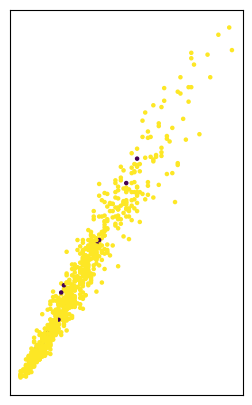

In [296]:
visualize_clusters(np.array(d1), result_SC_1)

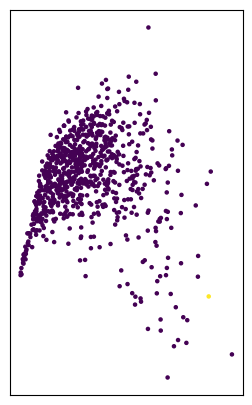

In [297]:
visualize_clusters(d2, result_SC_2)

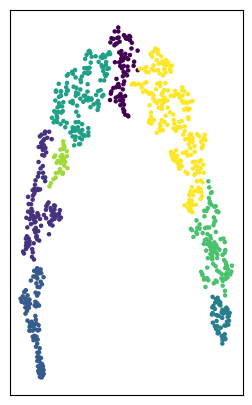

In [298]:
visualize_clusters(d3, result_SC_3)

In [299]:
claster_metrics( SpectralClustering(), np.array(d1), enc_oe[:,0], 'Data_D1')

/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:424: RuntimeWarning: overflow encountered in multiply
  distances = -2 * safe_sparse_dot(X, Y.T, dense_output=True)
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


,Dataset,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Data_D1,-0.000599,-0.000429,0.000994,0.072731,0.00196,0


In [300]:
claster_metrics( SpectralClustering(), d2, enc_oe[:,0], 'Data_D2')

/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited at iteration 783 with accuracies 
[6.24179049e-14 6.43301269e-06 9.25436298e-06 7.30514938e-06
 7.26396526e-06 1.66157863e-05 9.59205852e-06 1.13021117e-05
 1.19057767e-05]
not reaching the requested tolerance 1.2323260307312012e-05.
Use iteration 783 instead with accuracy 
8.852469286630376e-06.

  _, diffusion_map = lobpcg(
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited postprocessing with accuracies 
[3.47483937e-14 6.43301288e-06 9.25436392e-06 7.30514843e-06
 7.26396575e-06 1.66157863e-05 9.59205786e-06 1.13021117e-05
 1.19057766e-05]
not reaching the requested tolerance 1.2323260307312012e-05.
  _, di

,Dataset,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Data_D2,-0.000599,-0.000429,0.000994,0.072731,0.00196,0


In [301]:
claster_metrics( SpectralClustering(), d3, enc_oe[:,0], 'Data_D3')

,Dataset,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Data_D3,0.198215,0.297195,0.576229,0.20231,0.299476,0
